## Base DANSy Analysis

Using the base version of DANSy to analyze proteins of interest.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import dansy

First need to import a reference file that contains all the protein information. Here, we import a reference file for the entire proteome.

In [2]:
ref,_ = dansy.import_proteome_files(ref_file_dir='../', reference_file_suffix='Jan7_2025.csv')

Now building the DANSy object and showing the resulting network.

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


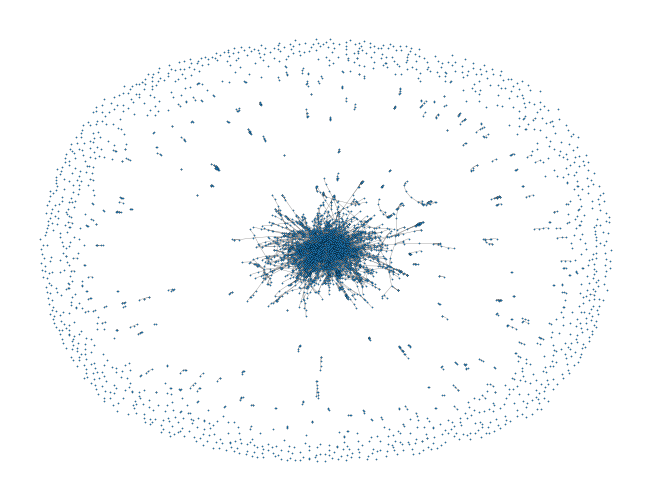

In [23]:
my_dansy = dansy.dansy(ref=ref)
my_dansy.draw_network()

## DANSy Analysis on a subset of proteins of interest

If we want to focus on a small subset of proteins rather than the whole proteome, we can provide a list of UniProt IDs in addition to the reference file.

For example, if we want to visualize the domain n-grams of the ERBB, FGFR, EPHA, and EPHB receptor tyrosine kinase families:

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


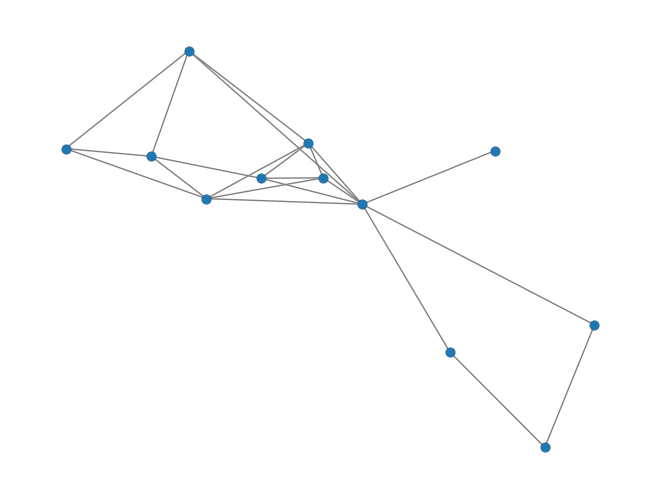

In [3]:
rtks = ['P00533','P04626','P21860','Q15303', # ERBB family
        'P11362','P21802','P22607','P22455', # FGFR family
        'P54764','P21709','P29317','P29322','P54756','Q15375','P29320','Q9UF33', # EPHA family
        'P29323','P54760','P54762','P54753'] # EPHB family

rtk_dansy = dansy.dansy(protsOI=rtks, ref=ref)

# Now just adjusting some aesthetics for the network
pos = nx.spring_layout(rtk_dansy.G, seed=123)
network_params = {'node_size':50,
                  'edgecolor':'k',
                  'width':1,
                  'linewdiths':0.25,
                  'pos':pos}

rtk_dansy.network_params = network_params

rtk_dansy.draw_network()

We can then extract all the n-grams by calling the ngram attribute

In [ ]:
rtk_dansy.collapsed_ngrams

52

However, these can be a little difficult to parse since the default values returned use the InterPro IDs rather than a human legible form. To convert these to the domain names we can use the return_legible_ngram method.

In [35]:
[rtk_dansy.return_legible_ngram(x) for x in rtk_dansy.ngrams]

['Prot_kinase_dom',
 'Ephrin_rcpt_lig-bd_dom',
 'FN3_dom|Eph_TM|Prot_kinase_dom|SAM',
 'FN3_dom|FN3_dom|Eph_TM|Prot_kinase_dom|SAM',
 'Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt-like|FN3_dom|FN3_dom|Eph_TM|Prot_kinase_dom|SAM',
 'Ephrin_rcpt_lig-bd_dom|FN3_dom',
 'Rcpt_L-dom|Furin-like_Cys-rich_dom|Rcpt_L-dom|GF_recep_IV',
 'Ig_sub2|Ig_sub2|Ig_sub2|Prot_kinase_dom',
 'Ephrin_rcpt_lig-bd_dom|FN3_dom|FN3_dom|Eph_TM|Prot_kinase_dom|SAM',
 'Rcpt_L-dom|Furin-like_Cys-rich_dom|Rcpt_L-dom|GF_recep_IV|TM_ErbB1|Prot_kinase_dom',
 'Ephrin_rcpt_lig-bd_dom|FN3_dom|Eph_TM|Prot_kinase_dom|SAM',
 'Rcpt_L-dom|Furin-like_Cys-rich_dom|Rcpt_L-dom|GF_recep_IV|Prot_kinase_dom']

## Useful DANSy attributes and methods for additional analysis

In [51]:
# The G attribute is a Graph object from the networkx package so any analysis that can be performed with the a networkx Graph can be used on the dansy.G

# Centrality measurements:
deg_cent = nx.degree_centrality(rtk_dansy.G)
btwn_cent = nx.betweenness_centrality(rtk_dansy.G)

# Connected components
conn_c = nx.connected_components(rtk_dansy.G)


In [38]:
# To get a summary of all the DANSy analysis
rtk_dansy.summary(detailed=True)

,
name,Domain n-gram Network
Proteins,20
n-grams,12
Network Isolates,0
Network Connected Components,1
Collapsed n-grams,52
Network Edges,22
Maximum Length of Protein Domain Architecture,7


In [39]:
# Getting protein information for a specific protein that was used for the analysis
rtk_dansy.retrieve_protein_info(prot = 'P00533')

,UniProt ID,Gene,Species,Uniprot Domains,Ref Sequence,PDB IDs,Uniprot Domain Architecture,Interpro Domains,Interpro Domain Architecture,Interpro Domain Architecture IDs
13158,P00533,EGFR,Homo sapiens,Protein kinase:712:979,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,1IVO;1M14;1M17;1MOX;1NQL;1XKK;1YY9;1Z9I;2EB2;2...,Protein kinase,Rcpt_L-dom:IPR000494:57:167;Furin-like_Cys-ric...,Rcpt_L-dom|Furin-like_Cys-rich_dom|Rcpt_L-dom|...,IPR000494|IPR006211|IPR000494|IPR032778|IPR049...


In [42]:
# Getting protein information for all proteins that have a specific ngram (e.g. 'FN3_dom|Eph_TM|Prot_kinase_dom|SAM':'IPR003961|IPR027936|IPR000719|IPR001660')
rtk_dansy.retrieve_protein_info(ngram='IPR003961|IPR027936|IPR000719|IPR001660')

,UniProt ID,Gene,Species,Uniprot Domains,Ref Sequence,PDB IDs,Uniprot Domain Architecture,Interpro Domains,Interpro Domain Architecture,Interpro Domain Architecture IDs
267,P29317,EPHA2,Homo sapiens,Eph LBD:28:206;Fibronectin type-III 1:328:432;...,MELQAARACFALLWGCALAAAAAAQGKEVVLLDFAAAGGELGWLTH...,1MQB;2E8N;2K9Y;2KSO;2X10;2X11;3C8X;3CZU;3FL7;3...,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:28:206;FN3_do...,Ephrin_rcpt_lig-bd_dom|FN3_dom|FN3_dom|Eph_TM|...,IPR001090|IPR003961|IPR003961|IPR027936|IPR000...
509,Q15375,EPHA7,Homo sapiens,Eph LBD:32:210;Fibronectin type-III 1:331:441;...,MVFQTRYPSWIILCYIWLLRFAHTGEAQAAKEVLLLDSKAQQTELE...,2REI;3DKO;3H8M;3NRU;7EEC;7EED;7EEF,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:32:210;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...
4248,P54762,EPHB1,Homo sapiens,Eph LBD:19:201;Fibronectin type-III 1:322:432;...,MALDYLLLLLLASAVAAMEETLMDTRTATAELGWTANPASGWEEVS...,2DJS;2EAO;3ZFX;5MJA;5MJB;6UMW;7KPL;7KPM,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:19:201;FN3_do...,Ephrin_rcpt_lig-bd_dom|FN3_dom|Eph_TM|Prot_kin...,IPR001090|IPR003961|IPR027936|IPR000719|IPR001660
5230,P54760,EPHB4,Homo sapiens,Eph LBD:17:202;Fibronectin type-III 1:323:432;...,MELRVLLCWASLAAALEETLLNTKLETADLKWVTFPQVDGQWEELS...,2BBA;2E7H;2HLE;2QKQ;2VWU;2VWV;2VWW;2VWX;2VWY;2...,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:17:202;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...
6258,P29323,EPHB2,Homo sapiens,Eph LBD:20:202;Fibronectin type-III 1:324:434;...,MALRRLGAALLLLPLLAAVEETLMDSTTATAELGWMVHPPSGWEEV...,1B4F;1F0M;2QBX;3ZFM,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:20:202;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...
8748,P54764,EPHA4,Homo sapiens,Eph LBD:30:209;Fibronectin type-III 1:328:439;...,MAGIFYFALFSCLFGICDAVTGSRVYPANEVTLLDSRSVQGELGWI...,2LW8;2WO1;2WO2;2WO3;3CKH;3GXU;4BK4;4BK5;4BKA;4...,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:30:209;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...
9669,P54756,EPHA5,Homo sapiens,Eph LBD:60:238;Fibronectin type-III 1:357:467;...,MRGSGPRGAGRRRPPSGGGDTPITPASLAGCYSAPRRAPLWTCLLL...,2R2P;4ET7,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:60:238;FN3_do...,Ephrin_rcpt_lig-bd_dom|FN3_dom|FN3_dom|Eph_TM|...,IPR001090|IPR003961|IPR003961|IPR027936|IPR000...
11351,Q9UF33,EPHA6,Homo sapiens,Eph LBD:34:212;Fibronectin type-III 1:331:441;...,MGGCEVREFLLQFGFFLPLLTAWPGDCSHVSNNQVVLLDTTTVLGE...,,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:34:212;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...
11849,P54753,EPHB3,Homo sapiens,Eph LBD:39:217;Fibronectin type-III 1:339:451;...,MARARPPPPPSPPPGLLPLLPPLLLLPLLLLPAGCRALEETLMDTK...,3P1I;3ZFY;5L6O;5L6P,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:39:217;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...
12914,P21709,EPHA1,Homo sapiens,Eph LBD:27:209;Fibronectin type-III 1:332:445;...,MERRWPLGLGLVLLLCAPLPPGARAKEVTLMDTSKAQGELGWLLDP...,2K1K;2K1L;3HIL;3KKA,Eph LBD|Fibronectin type-III 1|Fibronectin typ...,Ephrin_rcpt_lig-bd_dom:IPR001090:27:209;Tyr-ki...,Ephrin_rcpt_lig-bd_dom|Tyr-kin_ephrin_A/B_rcpt...,IPR001090|IPR011641|IPR003961|IPR003961|IPR027...


## Generating a DANSy without the collapsing step

A key step in DANSy is collapsing n-grams that are non-redundant, or in other words n-grams that represent the same family of proteins. This allows only domain n-grams that represent the maximum information in the network to be displayed. We can omit the collapsing step during the dansy object creation, but recommend only considering this step for small protein collections (<50) because the network can become difficult to understand otherwise.

In [43]:
rtk_dansy_uncollapsed = dansy.dansy(protsOI=rtks, ref=ref, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


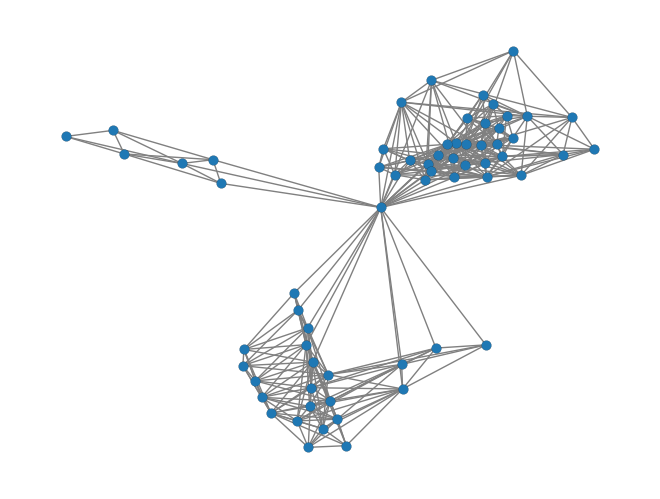

In [44]:
pos = nx.spring_layout(rtk_dansy_uncollapsed.G, seed=123)
network_params = {'node_size':50,
                  'edgecolor':'k',
                  'width':1,
                  'linewdiths':0.25,
                  'pos':pos}

rtk_dansy_uncollapsed.network_params = network_params

rtk_dansy_uncollapsed.draw_network()

In [47]:
rtk_dansy_uncollapsed.summary(detailed=True)

,
name,Domain n-gram Network
Proteins,20
n-grams,64
Network Isolates,0
Network Connected Components,1
Collapsed n-grams,0
Network Edges,389
Maximum Length of Protein Domain Architecture,7
